---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# Los rendimientos queseros

En este capítulo abordaremos el análisis de la eficiencia de la transformación quesera, mediante los indicadores del rendimiento quesero, que calcularemos a partir de los valores analíticos de la leche de fabricación y del queso recién elaborado. Extraeremos diversas conclusiones:

-   Estableceremos los parámetros de referencia de nuestro propio proceso, que nos servirán de punto de comparación para las fabricaciones que vayamos realizando.
-   Evaluaremos las causas posibles de las desviaciones, y veremos cómo proponer planes de acción para la reducción o eliminación de estas desviaciones.


## Un ejemplo de cálculo de rendimientos

En este ejemplo, vamos a suponer que elaboramos un queso de vaca, del que tenemos valores analíticos de producto terminado y de la leche utilizada en su elaboración. El proceso siempre tiene los mismos pasos tecnológicos, con la variabilidad que suponemos que es la habitual. 

Utilizaremos `Python` para el cálculo, al final se proporciona también una hoja de cálculo con la información necesaria.

Como siempre, es opcional descargar los datos de ejemplo y abrir el cuaderno en Colab para ejecutar el código a medida que se avanza en el estudio.

[Abrir este cuaderno en Google Colab](https://colab.research.google.com/github/juanriera/master-queseria/blob/master/085-intro-rendim.ipynb){target="_blank" rel="noopener noreferrer"}

[Descargar los datos de ejemplo utilizados en este cuaderno (archivo `fab_queso_bm.csv`)](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm.csv){target="_blank" rel="noopener noreferrer"}

## Lectura y exploración de los datos

Antes de lanzarnos al análisis cuantitativo, siempre es conveniente una primera visualización de los datos, por si hubiese algún valor que nos pueda resultar cuestionable. 

Es una mala práctica, aunque muy extendida, usar la hoja de cálculo para hacer la media aritmética de cada parámetro que vayamos a utilizar y trabajar con estos valores medios. En un conjunto de datos que recoja muchas fabricaciones, nunca podemos estar seguros de que el 100% de los valores sean correctos, que no haya habido errores de muestreo, analíticos o problemas de fabricación que hayan producido valores anormales. Por eso vamos a utilizar siempre los valores *medianos* y no los valores medios; como sabemos, la **mediana** es resistente a los valores anormales y extremos, mientras que la media no lo es.

Procedemos a leer los datos, y visualizamos las primeras lineas. Se incluye el código `python`que permite visualizar las tablas, en algunos casos se han formateado mediante `HTML`.

In [1]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_style("whitegrid")

# Python concatena automáticamente estas cadenas en diferentes
# líneas, escritas así para que el formato en A4 no se
# desborde por la derecha.
url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/fab_queso_bm.csv"
)

try:
    df = pd.read_csv(url_datos, 
                     decimal = ",", 
                     sep=';', 
                     encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y', # Formato Día/Mes/Año confirmado
    errors='coerce'    # convierte los valores que no puede leer a NaT
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

# Filtramos sólo queso de vaca para este capítulo
df = df[df['receta']=='vaca']

df.head()

,fecha,receta,litros_past,est_past,mg_past,mp_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,formato,est_salida_salmuera,mg_salida_salmuera,ph_salida_salmuera,peso_queso_total,sal_queso
fecha_index,,,,,,,,,,,,,,,,
2022-03-01,01/03/2022,vaca,15350,12.542,4.200,3.076,15810.99,11.37,4.01,2.94,barra,55.94,29.50,5.41,1960.0,1.55
2022-03-04,04/03/2022,vaca,14530,13.312,4.002,3.673,14989.74,13.25,3.79,3.45,barra,54.58,29.80,5.88,1888.0,1.77
2022-03-25,25/03/2022,vaca,12633,12.856,3.889,3.372,13011.79,12.89,3.69,3.21,barra,54.10,30.63,5.48,1555.0,1.32
2022-04-01,01/04/2022,vaca,15430,13.151,3.886,3.218,15946.80,11.88,3.71,3.02,barra,56.76,30.51,5.36,1750.0,1.36
2022-04-08,08/04/2022,vaca,15930,13.103,4.022,3.396,16452.76,11.93,3.81,3.23,barra,55.63,30.01,5.31,1955.0,1.90


Los datos se corresponden con un conjunto de fabricaciones de queso de vaca, como hemos dicho. Las principales variables recogidas son las siguientes:

In [2]:
#| echo: false

# Diccionario de variables con espacio para completar descripciones
descripcion_variables = {
    'fecha': 'Fecha de producción',
    'receta': 'Tipo de receta utilizada',
    'litros_past': 'Litros de leche pasteurizada',
    'est_past': 'Extracto seco total de la leche pasteurizada (g/100 ml leche)',
    'mg_past': 'Materia grasa de la leche pasteurizada (g/100 ml leche)',
    'mp_past': 'Materia proteica de la leche pasteurizada (g/100 ml leche)',
    'kg_cuba': 'Kilos totales de leche en la cuba',
    'est_cuba': 'Extracto seco total en cuba (g/100 g leche)',
    'mg_cuba': 'Materia grasa en cuba (g/100 g leche)',
    'mp_cuba': 'Materia proteica en cuba (g/100 g leche)',
    'lactosa_cuba': 'Contenido de lactosa en cuba (g/100 g leche)',
    'ph_final_moldeo_cuba': 'pH final antes del moldeo',
    'formato': 'Formato del queso una vez moldeado',
    'est_salida_salmuera': 'Extracto seco total tras salida de salado (g/100 g queso)',
    'mg_salida_salmuera': 'Materia grasa tras salida de salado (g/100 g queso)',
    'ph_salida_salmuera': 'pH tras salida de salado',
    'peso_queso_total': 'Peso total del queso producido (medido a la salida de la salmuera)',
    'sal_queso': 'Contenido de sal en el queso tras salida de salado (g/ 100 g queso)'
}

# Imprimir como tabla Markdown
# print("| Variable             | Descripción                                                            |")
# print("|----------------------|------------------------------------------------------------------------|")
# for variable, descripcion in descripcion_variables.items():
#     print(f"| {variable:<20} | {descripcion:<70} |")

# Construir tabla HTML
html = """
<table border="1">
    <thead>
        <tr>
           <th style="text-align:left;"><strong>Variable</strong></th>
           <th style="text-align:left;"><strong>Descripción</strong></th>
        </tr>
    </thead>
    <tbody>
"""

for variable, descripcion in descripcion_variables.items():
    html += f'        <tr><td style="text-align:left;">{variable}</td><td style="text-align:left;">{descripcion}</td></tr>\n'

html += "    </tbody>\n</table>"

# Mostrar en entorno compatible (como Jupyter Notebook)

display(HTML(html))



Variable,Descripción
fecha,Fecha de producción
receta,Tipo de receta utilizada
litros_past,Litros de leche pasteurizada
est_past,Extracto seco total de la leche pasteurizada (g/100 ml leche)
mg_past,Materia grasa de la leche pasteurizada (g/100 ml leche)
mp_past,Materia proteica de la leche pasteurizada (g/100 ml leche)
kg_cuba,Kilos totales de leche en la cuba
est_cuba,Extracto seco total en cuba (g/100 g leche)
mg_cuba,Materia grasa en cuba (g/100 g leche)
mp_cuba,Materia proteica en cuba (g/100 g leche)


## Rendimiento simple
Por esta razón, debemos calcular el rendimiento mediante parámetros que no se vean afectados por la humedad del queso, sino que reflejen con precisión la calidad del trabajo quesero. La mejor forma de hacerlo consiste en calcular el porcentaje de materia quesera que hemos sido capaces de retener en el queso. Dado que los elementos de valor de la leche, que son los que se utilizan en el pago por calidad, son la materia grasa y la proteína, calcularemos la recuperación de materia grasa, de materia proteica y de extracto seco magro. 

Estos valores son propios de cada tecnología quesera, y cada uno sirve de referencia para comprender cuáles son los diferentes problemas en fabricación, 

* Una mala retención de materia grasa
* Una mala retención de proteína
* Una mala retención de extracto seco magro

---


El laboratorio nos facillita la información analítica de la leche pasteurizada en porcentaje masa/volumen, mientas que la leche en cubas y el queso es masa/masa. Esto es así porque la cantidad de leche que pasa por el pasteurizador se mide con un contador volumétrico, mientras que en la cuba se mide con una célula de carga.

Si el volumen de leche en cuba se midiese también con contador volumétrico, necesitaríamos convertir los resultados analíticos a masa/volumen para obtener los kilos de cada materia, utilizando la densidad.

En la práctica, usar una densidad promedio fija o ajustada por estaciones funciona bastante bien, y evita los errores de medida de este parámetro que parecen sencillos pero siempre están sometidos al error de muestreo, además de la necesidad de corregir la temperatura.



Veamos los datos analíticos del queso

In [3]:
#| echo: false

# Calcular media y mediana
media_est = df['est_salida_salmuera'].mean()
mediana_est = df['est_salida_salmuera'].median()

media_mg = df['mg_salida_salmuera'].mean()
mediana_mg = df['mg_salida_salmuera'].median()

# Crear tabla HTML
html = f"""
<table border="1">
    <thead>
        <tr>
            <th><strong>Composición del queso</strong></th>
            <th><strong>Media (g/100 g)</strong></th>
            <th><strong>Mediana (g/100 g)</strong></th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>EST a salida de salado</td>
            <td>{media_est:.2f}%</td>
            <td>{mediana_est:.2f}%</td>
        </tr>
        <tr>
            <td>MG a salida de salado</td>
            <td>{media_mg:.2f}%</td>
            <td>{mediana_mg:.2f}%</td>
        </tr>
    </tbody>
</table>
"""

# Mostrar tabla en notebook
display(HTML(html))

Composición del queso,Media (g/100 g),Mediana (g/100 g)
EST a salida de salado,55.16%,54.85%
MG a salida de salado,29.74%,29.80%


Para hacer este producto, estamos trabajando con una leche que hemos enriquecido en MG y MP, cuya composición es:

In [4]:
#| echo: false

# Calcular medias y medianas desde df
media_est = df['est_cuba'].mean()*10
mediana_est = df['est_cuba'].median()*10

media_mg = df['mg_cuba'].mean()*10
mediana_mg = df['mg_cuba'].median()*10

media_mp = df['mp_cuba'].mean()*10
mediana_mp = df['mp_cuba'].median()*10

# Crear tabla HTML
html = f"""
<table border="1">
    <thead>
        <tr>
            <th style="text-align:left;"><strong>Composición materia prima</strong></th>
            <th style="text-align:left;"><strong>Media (g/L)</strong></th>
            <th style="text-align:left;"><strong>Mediana (g/L)</strong></th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:left;">Extracto seco total (ESM)</td>
            <td style="text-align:left;">{media_est:.2f}</td>
            <td style="text-align:left;">{mediana_est:.2f}</td>
        </tr>
        <tr>
            <td style="text-align:left;">Materia grasa (MG)</td>
            <td style="text-align:left;">{media_mg:.2f}</td>
            <td style="text-align:left;">{mediana_mg:.2f}</td>
        </tr>
        <tr>
            <td style="text-align:left;">Proteínas totales (MP)</td>
            <td style="text-align:left;">{media_mp:.2f}</td>
            <td style="text-align:left;">{mediana_mp:.2f}</td>
        </tr>
    </tbody>
</table>
"""

# Mostrar en entorno compatible (como Jupyter Notebook)
display(HTML(html))

Composición materia prima,Media (g/L),Mediana (g/L)
Extracto seco total (ESM),123.17,119.30
Materia grasa (MG),38.48,38.10
Proteínas totales (MP),31.98,32.10


## Cálculo de la cantidad de leche necesaria para fabricar 1 kg de queso

Sabemos que nuestro proceso de fabricación quesera consiste en la coagulación de la caseína y expulsión de suero, y que la materia grasa queda retenida en la red de caseína.

Este concepto es la base fundamental de la comprensión de la tecnología quesera: es el rendimiento en la recuperación de la proteína el que nos va a definir todo el proceso, la materia grasa “acompañará” de forma estática (aunque tendrá influencia en el desuerado)

Por esta razón, el principal elemento del rendimiento en la definición de la tecnología es el porcentaje de recuperación de proteína en el extracto seco magro (aislamos el efecto la grasa)

Hemos definido nuestro producto mediante los análisis de EST y MG; necesitamos saber el resto de parámetros, en concreto el ESM que estamos definiendo para nuestro producto:


In [5]:
#| echo: false

# Calcular medias y medianas
media_est = df['est_salida_salmuera'].mean()
mediana_est = df['est_salida_salmuera'].median()

media_mg = df['mg_salida_salmuera'].mean()
mediana_mg = df['mg_salida_salmuera'].median()

# Calcular ESM (Extracto Seco Magro)
media_esm = media_est - media_mg
mediana_esm = mediana_est - mediana_mg

# Calcular índice MG/EST correctamente
media_mg_est = (media_mg / media_est) * 100
mediana_mg_est = (mediana_mg / mediana_est) * 100

# Crear tabla HTML
html = f"""
<table border="1">
    <thead>
        <tr>
            <th style="text-align:left;"><strong>Composición del queso</strong></th>
            <th style="text-align:left;"><strong>Media (g/100 g)</strong></th>
            <th style="text-align:left;"><strong>Mediana (g/100 g)</strong></th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:left;">EST a salida de salado</td>
            <td style="text-align:left;">{media_est:.2f}%</td>
            <td style="text-align:left;">{mediana_est:.2f}%</td>
        </tr>
        <tr>
            <td style="text-align:left;">MG a salida de salado</td>
            <td style="text-align:left;">{media_mg:.2f}%</td>
            <td style="text-align:left;">{mediana_mg:.2f}%</td>
        </tr>
        <tr>
            <td style="text-align:left;">ESM a salida de salado)</td>
            <td style="text-align:left;">{media_esm:.2f}%</td>
            <td style="text-align:left;">{mediana_esm:.2f}%</td>
        </tr>
        <tr>
            <td style="text-align:left;">MG/EST a salida de salado</td>
            <td style="text-align:left;">{media_mg_est:.2f}%</td>
            <td style="text-align:left;">{mediana_mg_est:.2f}%</td>
        </tr>
    </tbody>
</table>
"""

# Mostrar tabla en notebook
display(HTML(html))

Composición del queso,Media (g/100 g),Mediana (g/100 g)
EST a salida de salado,55.16%,54.85%
MG a salida de salado,29.74%,29.80%
ESM a salida de salado),25.42%,25.05%
MG/EST a salida de salado,53.91%,54.33%


Ahora necesitamos conocer cuál es la tasa o ratio de conversión en ESM de queso del ESM, o bien de la MP, de la leche en cubas. Para ello calculamos estos ratios, que vamos a llamar **coeficiente de recuperación de ESM**, y el **coeficiente de recuperación de MP** junto con el **coeficiente de recuperación de MG**,que indicará la cantidad de MG que somos capaces de recuperar en el queso.

Si la recuperación de MG fuese perfecta, el coeficiente de recuperación sería 100%. El coeficiente refleja que hay pérdidas de MG, bien en el suero, bien en los finos de moldeo o en cuajada que se ha caído, etc, en resumen, que no ha ido a parar al queso moldeado. Podemos argumentar, correctamente, que la parte de los finos recoge también la eficiencia de la coagulación, pero al final lo que nos interesa es recoger la conversión real en queso de nuestra materia prima, excluyendo todo lo que constituyen las **pérdidas de proceso**.

El **coeficiente de recuperación de ESM** tiene un valor mucho más bajo, porque hay una parte significativa del ESM de la leche que vamos a perder en el suero y durante el salado, como las proteínas solubles, la lactosas y las sales minerales; por otra parte, vamos a incorporar a ese ESM la sal añadida durante el salado.

Lo importante es que el valor de este coeficiente, si nuestro proceso es estable, debe ser siempre constante: en un proceso estable, tanto las pérdidas como las ganancias deben ser muy semejantes de un día a otro, si las condiciones del proceso se han mantenido. Por lo tanto, lo que nos interesa es este valor *mediano* del coeficiente, y debemos asegurarnos de que es regular.

EL último coeficiente, el **coeficiente de recuperación de MP** se basa en esta misma regularidad del proceso para establecer la relación entre la proteína puesta en cuba y el ESM del queo. La ventaja de este coeficiente es que con los medios analíticos habituales, es más fácil analizar la leche mediante un NIR (*near-infrared*) como el MilkoScan, que hacer un extraco seco convencional en estufa.

In [6]:
### 1. Cálculos de cuba
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de queso 
### ejemplo de cómo poner fórmulas largas para que no desborden
### la línea
df['est_kg_queso'] = (
    df['peso_queso_total'] * df['est_salida_salmuera'] / 100
)
df['mg_kg_queso'] = (
    df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
)

df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba'] * 100
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] * 100 
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba'] * 100

print(
    f"Coeficiente de recuperación de materia grasa "
    f"(MG queso/MG leche en cuba): "
    f"{df['coef_recup_mg'].mean():.3f}"
)

print(
    f"Coeficiente de recuperación de proteína "
    f"(ESM queso/MP leche en cuba): "
    f"{df['coef_recup_mp'].mean():.3f}"
)

print(
    f"Coeficiente de recuperación de extracto seco magro "
    f"(ESM queso/ESM leche en cuba): "
    f"{df['coef_recup_esm'].mean():.3f}"
)


Coeficiente de recuperación de materia grasa (MG queso/MG leche en cuba): 91.694
Coeficiente de recuperación de proteína (ESM queso/MP leche en cuba): 94.457
Coeficiente de recuperación de extracto seco magro (ESM queso/ESM leche en cuba): 35.949


A partir de aquí, hacemos los cálculos teóricos del estándar técnico.

Utilizando el coeficiente de recuperación de la MP, podemos calcular la cantidad de ESM que vamos a recuperar. La mediana de la cantidad de proteína que tenemos en la leche es 32,10 g/L; sabemos que con 1 L de leche vamos a obtener en el queso

$$
\frac{32.10\ g\ proteína}{1\ L\ leche}*\ \frac{0.94457\ g\ ESM}{1\ g\ proteína} = 30.32\ g\ ESM\ en\ el\ queso\ por\ litro\ de\ leche
$$


Esta es la conversión clave de nuestra tecnología, y es conocida como ***coeficiente G*** en honor a su autor, Antoine M Guérault, que lo introdujo formalmente por primera vez por en su libro *La fromagerie devant les techniques nouvelles,* en 1966; desde entonces sigue utilizándose con plena validez. Originalmente, el coeficiente indica el porcentaje de ESM que hemos recuperado en el queso, dividiendo el ESM del queso entre el ESM de la leche puesta en fabricación, aunque es más habitual usar el coeficiente de recuperación de proteína en vez del de ESM, como hemos hecho arriba. 

Como comentamos más atrás, para una tecnología concreta, normalmente la cantidad de sal incluida en el salado y las pérdidas de ESM en el proceso de fabricación deberían mantenerse en una horquilla más o menos estrecha, de acuerdo con la variabilidad de nuestro proceso y nuestra precisión analítica. Si el valor del coeficiente se mantiene en estos límites, nos indicará que la transformación se ha realizado dentro de los valores normales de la tecnología; en caso contrario, si hemos tenido valores anormalmente altos o bajos, será indicador de incidencias tecnológicas que intentaremos explicar para poner en marcha acciones correctivas. En este capítulo veremos el cálculo de los índices; en un capítulo posterior abordaremos el análisis de las desviaciones. 

Como sabemos la cantidad de ESM que vamos a obtener de 1 L de leche, podemos calcular los litros de leche que necesitamos para obtener 1 kg de queso mediante una conversión simple. A este valor lo llamaremos *litraje unitario*.

$$
\text{Litraje unitario} = \frac{25.05\ g\ ESM}{100\ g\ queso\ }*\ \frac{1000\ g\ queso}{1\ kg\ queso}*\ \frac{1\ L\ leche}{30,32\ g\ ESM} = 8,261\ L\ leche\ para\ hacer\ 1\ kg\ de\ queso
$$

y el consumo de MP por kilo de queso es el que resulta de calcular

$$
8,261\ L\ leche*\ \frac{32.10\ g\ MP}{1\ L\ leche} = 265,18\ g\ MP\ por\ kilo\ de\ queso
$$


In [7]:
### 5. Litrajes unitarios: (g ESM en queso por kilo de queso) / (g MP leche en cuba por litro de leche) 
df['litraje_unitario']  = (df['esm_kg_queso']/df['peso_queso_total']) * 100 / ((df['mp_cuba'] / 100 ) * df['coef_recup_mp'])

### 6. Consumos de materia por kilo de queso (g / kg)
df['consumo_mg_kg']  = df['mg_kg_cuba']/df['peso_queso_total'] * 1000
df['consumo_mp_kg']  = df['mp_kg_cuba']/df['peso_queso_total'] * 1000 


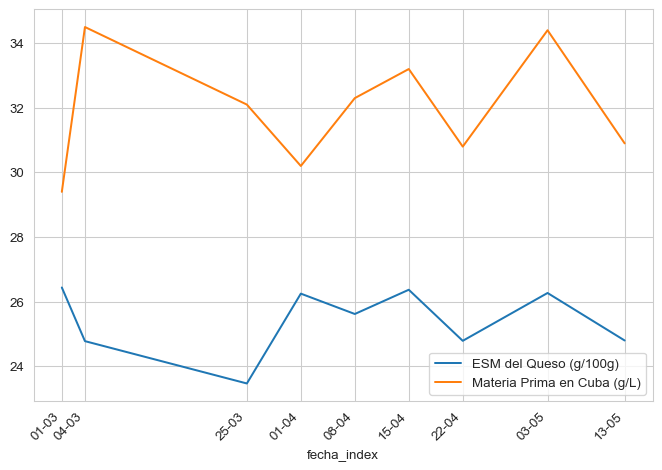

In [8]:
import matplotlib.dates as mdates

esm_queso = df['esm_kg_queso'] / df['peso_queso_total'] * 100
mp_cuba = df['mp_cuba'] * 10

# 1. Graficar y capturar los ejes
ax = esm_queso.plot(label='ESM del Queso (g/100g)')
mp_cuba.plot(label='Materia Prima en Cuba (g/L)', ax=ax)

# 2. Definir y aplicar el formateador
# Usamos "%d-%m" para mostrar Día-Mes sin el año.
ax.set_xticks(df.index)
date_form = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_form)

# 3. Ajustes de visualización
plt.xticks(rotation=45) 
plt.legend()
plt.tight_layout() # Ajusta automáticamente el gráfico para que las etiquetas no se corten
plt.show()

Es necesario insistir en que estos cálculos teóricos sólo son válidos en nuestras condiciones de trabajo precisas:

-   con la composición en ESM de nuestro queso

-   con la composición de proteína de nuestra leche

-   con la tasa de recuperación de la proteína de la leche en el ESM del queso de nuestro específico proceso de fabricación.

Son valores teóricos que utilizamos como valor objetivo, y que pueden variar a medida que adaptemos o variemos nuestra tecnología. Para cualquier otro producto, otra composición de leche y/u otro proceso de fabricación, deberemos recalcular nuestro litraje por kilo y nuestro consumo de materia.

Sabemos que, en nuestras condiciones, 8,261 L de leche deben darnos 1 kg de queso. Si obtenemos más o menos queso querrá decir que nuestras hipótesis de partida no se han cumplido, y analizando los tres elementos básicos, sabremos la razón de la desviación:

-   Nuestra leche tiene una composición diferente

-   Nuestro queso tiene una composición diferente

-   Nuestra recuperación de proteína ha sido diferente.

Si disponemos de la analítica correspondiente, podremos tomar las decisiones correctas; no es lo mismo actuar ante un problema de composición de leche que ante un problema de composición de queso o un problema de tecnología quesera (el extracto seco magro del queso es consecuencia de la tecnología quesera). Otros factores pueden influir directamente en el coeficiente de recuperación de proteína, por ejemplo, la cantidad de proteína coagulable (caseína) frente a la proteína total analizada puede variar a lo largo del año, y el análisis de proteína total no nos da una indicación de esta ratio.

## La materia grasa

Hasta aquí hemos hablado de proteína y ESM, pero ¿y la materia grasa?

En nuestro análisis de rendimiento hemos calculado también un % de recuperación de MG. Sin embargo, no utilizaremos este % para calcular el litraje, lo haremos tal como hemos visto, con la transformación de la proteína en ESM. La razón es que *la tecnología quesera nos permite actuar sobre el ESM del queso, pero la MG depende de la estandarización*, como veremos a continuación.

Como el cálculo que hemos realizado con el coeficiente de recuperación de la MP nos da los litros de leche que necesitamos para hacer 1 kg de queso, y tenemos una composición de nuestra leche, podemos saber la cantidad de MG que vamos a tener en esos litros. Por otra parte, sabemos la MG que hemos definido en nuestro queso de forma empírica, es decir, en la práctica: mediante un promedio de los diferentes análisis de nuestro producto que hemos ido obteniendo.

Hemos calculado nuestro litraje unitario: necesitamos 8,261 L leche para hacer 1 kg de queso.

Según nuestra composición de leche, 1 L de leche tiene 38,10 g de MG, luego los 8,261 L de leche tendrán

$$
8,261\ L\ leche*\ \frac{38.10\ g\ MG}{1\ L\ leche} = 314,74\ g\ MG
$$

Es decir, para fabricar 1 kg de queso necesitamos 8.261 L leche, que según su composición tienen 314,74 g MG

Sin embargo, la analítica de nuestro queso nos dice que en 1 kg de queso tenemos 29.80% de MG, es decir 298.0 g de MG por kilo de queso.

¿A qué se debe esta diferencia? La respuesta es: *a las pérdidas de MG en el proceso*, es decir, *a nuestro porcentaje de recuperación de MG.*

Podemos calcular este porcentaje mediante la fracción

$$
\frac{MG\ en\ el\ queso}{MG\ en\ la\ leche\ de\ fabricación}\ =\ \frac{298,0\ g\ MG/kg\ en\ el\ queso}{314,74\ g\ MG/kg\ en\ la\ leche\ de\ fabricación} = 0,9468
$$

Es decir, nuestra recuperación teórica de MG es del 94.68%

¿Por qué *recuperación teórica*? Porque es la que resulta de hacer los cálculos según nuestros datos de composición de leche, composición del queso y recuperación de proteína, no de los análisis realizados.

De la misma forma que en el caso de la recuperación de proteína, si nuestra recuperación de MG es diferente de la calculada teóricamente, debemos encontrar la explicación en los mismos factores:

-   Composición real de la leche

-   Composición real del queso

-   Variaciones en la tecnología

Estas variaciones pueden implicar una mayor pérdida de MG, en el suero de quesería o en los finos de queso (o en ambos), y que en parte puede recuperarse mediante un desnatado del suero.

## El estándar de fabricación o estándar técnico

Como hemos visto, la construcción del estándar técnico y el seguimiento de la tecnología quesera no se hacen siguiendo el consumo de *litros de leche*, sino de la cantidad de proteína y grasa utilizadas. Por esta razón, la construcción del estándar debe proporcionar las cantidades de MG y MP necesarias para obtener 1 kg de queso, y no sólo el litraje en cuba.

El razonamiento y cálculos que hemos ido realizando, se suelen recoger en lo que se llama un *estándar técnico de fabricación*. Este documento recoge los valores estándar de nuestra tecnología dada una composición media de nuestro queso obtenido (o un objetivo a obtener) y una composición de leche de partida. Al final del capítulo se puede descargar una hoja Excel con el estándar de fabricacion que hemos ido construyendo para nuestro queso de vaca.

Llamamos **MG teórica en la cuba** a la cantidad de MG que calculamos que vamos a tener en la cuba, es decir, en nuestros 8,261 L de leche a fabricar. Esta MG puede provenir de la leche de partida o del resultado de estandarizar la leche en MG,  añadiendo nata o bien leche desnatada, para conseguir la cantidad de MG que nos permita alcanzar los valores de MG deseada en el queso.

De la misma forma, llamamos **MP en cuba** a la cantidad de MP que hemos puesto en cuba, ya sea la de la leche de partida o del resultado de haber estandarizado la leche mediante el añadido de proteínas.

En el caso de nuestro queso de vaca, vemos un proceso de fabricación que *no* usa estandarización y que no está recuperando la materia grasa del suero; las diferencias entre la MG en cuba y la MG en el queso se consideran pérdidas de proceso y su reducción es un objetivo prioritario del proceso de mejora.

## La importancia de la estandarización de la leche

La tecnología quesera se diseña para optimizar el coeficiente de recuperación de proteína. Aunque la retención de materia grasa (MG) también depende de factores tecnológicos como el corte, el calentamiento y el pH, no está directamente controlada por la tecnología, aunque sí influenciada por ella.

En una tecnología concreta, con parámetros de trabajo fijados, cuando la cantidad de MG en la leche es superior a la definida en el proceso, se producen dos efectos:

-   Una parte del exceso de MG queda retenida en la matriz proteica, lo que incrementa la cantidad de grasa en el queso y, por tanto, modifica su composición.

-   Otra parte de la MG se pierde en el suero, ya que las condiciones del proceso determinan una relación fija con la cantidad total de MG de partida. Es decir, al aumentar la MG inicial, también aumentan las pérdidas relativas en el suero.

Desgraciadamente, no es posible calcular teóricamente cuánta MG se retendrá en el queso y cuánta se perderá en el suero, ya que estas cantidades no responden a una función conocida. Lo que sí sabemos es que:

-   Aumentarán las pérdidas.

-   Se modificará la composición del queso, lo que puede alterar su textura y el valor nutricional declarado.

-   Se alterará la expulsión de suero de la matriz proteica, lo que afectará la cantidad de lactosa retenida en la cuajada y, en consecuencia, las curvas de acidificación, el extracto seco, etc.

Cuando la MG es *inferior* a la definida, estos efectos se producen en sentido inverso, afectando tanto la composición del queso como su comportamiento tecnológico.

Para minimizar estas variaciones y mantener una composición constante del producto, es necesario:

-   Trabajar con leche que tenga un contenido estable de materia grasa (MG) y materia proteica (MP). Dado que la composición de la leche varía estacionalmente, esto implica estandarizarla en MG y MP, **manteniendo constante la relación MG/MP**.

-   Adaptar la tecnología de forma estacional, ya que la variación estacional no solo afecta la relación MG/MP, sino también la proporción de caseína coagulable dentro del total de proteínas.

Es fundamental recordar lo señalado al definir el estándar técnico: *la tecnología permite modificar el extracto seco magro (ESM) del queso, pero la MG depende principalmente de la cantidad presente en la leche de fabricación*. **No es posible modificar la cantidad de grasa en el queso mediante la tecnología quesera en la cuba**; es necesario preparar la leche con la cantidad de grasa adecuada para cubrir tanto la retención esperada como las pérdidas previstas.

En la medida en que no se puedan realizar estas adaptaciones, se deberá aceptar una mayor variabilidad en el producto, con dos consecuencias:

-   Irregularidad en el producto final, que afecta la aceptación por parte del consumidor.

-   Variación en el coste del producto, que puede dar lugar a pérdidas económicas no previstas.

Por estas razones, es imprescindible realizar un seguimiento detallado de las desviaciones tecnológicas, para comprender mejor el comportamiento del proceso y actuar eficazmente sobre sus causas. Las desviaciones observadas deben analizarse siempre apoyándose en el conocimiento tecnológico, para que los planes correctivos sean eficaces.

Conociendo el coste de la MG y de la MP pagada, es posible calcular el valor económico de cada desviación, lo que permite priorizar las acciones correctivas según su impacto financiero. El análisis de las desviaciones se hace en un capítulo posterior.

Hay una hoja Excel con todos los cálculos, que incluye también los estándares de fabricacion que veremos en el capítulo siguiente para el resto de recetas.


[Abrir hoja Excel con estándar técnico](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/2025-11-06-ejemplo-std-tecnico.xlsx){target="_blank" rel="noopener noreferrer"}

Veamos las características de los quesos, excluyendo ya los ensayos de I+D

In [9]:
df['esm_salida_salmuera'] = df['est_salida_salmuera']-df['mg_salida_salmuera']
df['hqd_salida_salmuera'] = (100 - df['est_salida_salmuera'])/(100 - df['mg_salida_salmuera'])
df['ges_salida_salmuera'] = df['mg_salida_salmuera'] / df['est_salida_salmuera']

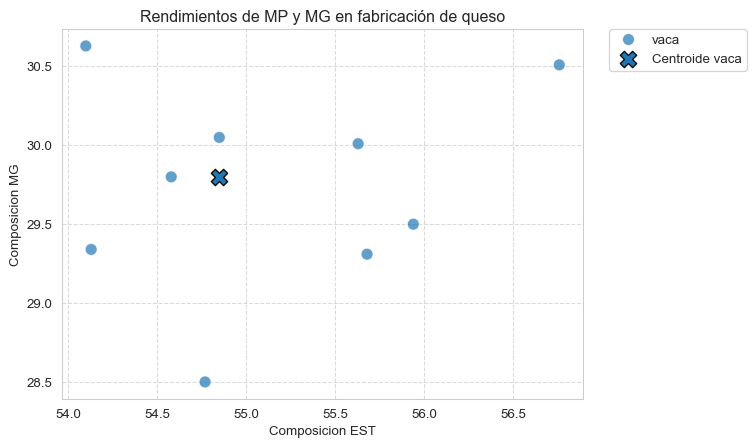

In [10]:

# Filtrar receta 'i+D'
df_filtrado = df[df['receta'] != 'i+D'].reset_index(drop=True)

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='est_salida_salmuera', 
                y='mg_salida_salmuera', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_est_mg = df.groupby('receta')[['est_salida_salmuera', 'mg_salida_salmuera']].median()

for receta in recetas:
    centro = centroides_est_mg.loc[receta]
    plt.scatter(
        centro['est_salida_salmuera'],
        centro['mg_salida_salmuera'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Composicion EST')
plt.ylabel('Composicion MG')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [11]:
print(centroides_est_mg)

        est_salida_salmuera  mg_salida_salmuera
receta                                         
vaca                  54.85                29.8


In [12]:
df.head()

,fecha,receta,litros_past,est_past,mg_past,mp_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,...,sal_kg_queso,coef_recup_mg,coef_recup_mp,coef_recup_esm,litraje_unitario,consumo_mg_kg,consumo_mp_kg,esm_salida_salmuera,hqd_salida_salmuera,ges_salida_salmuera
fecha_index,,,,,,,,,,,,,,,,,,,,,
2022-03-01,01/03/2022,vaca,15350,12.542,4.200,3.076,15810.99,11.37,4.01,2.94,...,30.3800,91.195761,111.483637,44.532866,8.066832,323.479948,237.164850,26.44,0.624965,0.527351
2022-03-04,04/03/2022,vaca,14530,13.312,4.002,3.673,14989.74,13.25,3.79,3.45,...,33.4176,99.034142,90.466981,32.992715,7.939481,300.906327,273.912092,24.78,0.647009,0.545988
2022-03-25,25/03/2022,vaca,12633,12.856,3.889,3.372,13011.79,12.89,3.69,3.21,...,20.5260,99.200527,87.377860,30.487275,8.367711,308.768522,268.603511,23.47,0.661669,0.566174
2022-04-01,01/04/2022,vaca,15430,13.151,3.886,3.218,15946.80,11.88,3.71,3.02,...,23.8000,90.247005,95.386490,35.259143,9.112457,338.072160,275.196206,26.25,0.622248,0.537526
2022-04-08,08/04/2022,vaca,15930,13.103,4.022,3.396,16452.76,11.93,3.81,3.23,...,37.1450,93.594218,94.250704,37.491351,8.415734,320.639466,271.828209,25.62,0.633948,0.539457


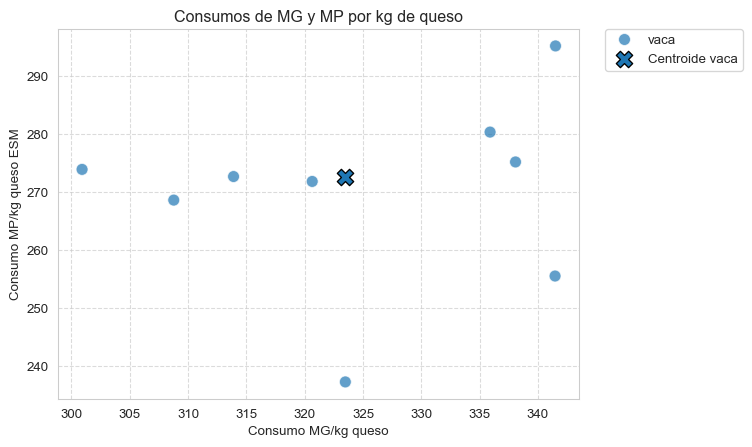

In [13]:
# Crear paleta de colores por receta
recetas = df['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='consumo_mg_kg', 
                y='consumo_mp_kg', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_consumos_materia = df.groupby('receta')[['consumo_mg_kg', 'consumo_mp_kg']].median()

for receta in recetas:
    centro = centroides_consumos_materia.loc[receta]
    plt.scatter(
        centro['consumo_mg_kg'],
        centro['consumo_mp_kg'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Consumos de MG y MP por kg de queso')
plt.xlabel('Consumo MG/kg queso')
plt.ylabel('Consumo MP/kg queso ESM')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
